# Машинное обучение, РЭШ

# Практическое задание 7. Бустинговое

## Общая информация

Дата выдачи: 10.12.2022

Дедлайн: 25.12.2022 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему mynes. Посылка должна содержать:
* Ноутбук homework-practice-07-Username.ipynb
* Файл [boosting.py](https://github.com/esokolov/ml-course-hse/tree/master/2021-fall/homeworks-practice/homework-practice-07-boosting)

Username — ваша фамилия на латинице

## О задании

В этом задании вам предстоит вручную запрограммировать один из самых мощных алгоритмов машинного обучения — бустинг.

In [1]:
from warnings import filterwarnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.ndimage import gaussian_gradient_magnitude
from scipy.sparse import load_npz
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold

sns.set_style(style='darkgrid')
filterwarnings('ignore')

In [2]:
def pprint(*args, **kwargs):
    print(">>", *args, **kwargs)

[Ссылка на данные](https://github.com/esokolov/ml-course-hse/tree/master/2021-fall/homeworks-practice/homework-practice-07-boosting)

In [3]:
x = load_npz('data/x.npz')
y = np.load('data/y.npy')

Разделим на обучающую, валидационную и тестовую выборки (`random_state` оставьте равным 1337 для воспроизводимости).

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1337)
x_test, x_valid, y_test, y_valid = train_test_split(x_test, y_test, test_size=0.5, random_state=1337)
x_train.shape, x_valid.shape, x_test.shape

((18825, 169), (2354, 169), (2353, 169))

## Задание 1. Реализация градиентного бустинга (4 балла)

Вам нужно дописать код в файлике `boosting.py`. Для вас уже подготовлен шаблон класса `Boosting`, вы можете менять его по своему усмотрению.

### Инструкции для функций:

#### `__init__`

В `__init__` приходит кучка параметров, распишем что есть что:

 - `base_model_class` - класс базовой модели нашего бустинга
 - `base_model_params` - словарь с гиперпараметрами для базовой модели
 - `n_estimators` - какое количество базовых моделей нужно обучить
 - `learning_rate` - темп обучения, должен быть из полуинтервала $(0, 1]$
 - `subsample` - доля объектов, на которой будет обучаться базовая модель (какую часть составляет бутстрапная выборка от исходной обучающей)
 - `early_stopping_rounds` - число итераций, после которых при отсутствии улучшения качества на валидационной выборке обучение останавливается
 - `plot` - строить ли после обучения всех базовых моделей график с качеством

#### `fit`

В `fit` приходит две выборки, обучающая и валидационная. На обучающей мы обучаем новые базовые модели, на валидационной считаем качество для ранней остановки (если это предусматривают параметры).

Сначала нам нужно сделать какую-то нулевую модель, сделать предсказания для обучающей и валидационной выборок (в шаблоне это нулевая модель, соответственно предсказания это просто `np.zeros`). После этого нужно обучить `n_estimators` базовых моделей (как и на что обучаются базовые модели смотрите в лекциях и семинарах). После каждой обученной базовой модели мы должны обновить текущие предсказания, посчитать ошибку на обучающей и валидационной выборках (используем `loss_fn` для этого), проверить на раннюю остановку.

После всего цикла обучения надо нарисовать график (если `plot`).


#### `fit_new_base_model`

В `fit_new_base_model` приходит обучающая выборка (целиком) и текущие предсказания для неё. Мы должны сгенерировать бутстрап выборку для обучения базовой модели и обучить базовую модель. После обучения модели запускаем поиск оптимальной гаммы, добавляем новую модель и гамму (не забываем про темп обучения) в соответствующие списки.

#### `predict_proba`

В `predict_proba` приходит выборка, нужно предсказать вероятности для неё. Суммируем предсказания базовых моделей на этой выборке (не забываем про гаммы) и накидываем сигмоиду.

In [50]:
from collections import defaultdict

import numpy as np
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeRegressor

sns.set_style(style="darkgrid")


class Boosting:

    def __init__(
            self,
            base_model_params: dict = None,
            n_estimators: int = 10,
            learning_rate: float = 0.1,
            subsample: float = 0.3,
            early_stopping_rounds: int = None,
            plot: bool = False,
    ):
        self.base_model_class = DecisionTreeRegressor
        self.base_model_params: dict = {} if base_model_params is None else base_model_params

        self.n_estimators: int = n_estimators

        self.models: list = []
        self.gammas: list = []

        self.learning_rate: float = learning_rate
        self.subsample: float = subsample

        self.early_stopping_rounds: int = early_stopping_rounds

        self.plot: bool = plot

        # history for loss on tran and validation sets
        self.history = defaultdict(list)

        self._sigmoid = lambda x: 1 / (1 + np.exp(-x))

        # logistic loss function
        self._loss_fn = lambda y, z: -np.log(self._sigmoid(y * z)).mean()

        # first order derivative (of the function above)
        self._loss_derivative = lambda y, z: -y * self._sigmoid(-y * z)

        # second order derivative (unused)
        self._loss_derivative2 = lambda y, z: y ** 2 * self._sigmoid(-y * z) * (1 - self._sigmoid(-y * z))

    def fit_new_base_model(self, x, y, predictions):

        # base models are by design selected simple (hence low capacity)
        # however, the training set of objects is sizable
        # to compensate it, the idea is, following stochastic gradient descent fashion, to use a subsample of X
        rand_idx = np.random.choice(x.shape[0], size=int(x.shape[0]*self.subsample), replace=True)
        x_sample = x[rand_idx]
        y_sample = y[rand_idx]
        predictions_sample = predictions[rand_idx]

        # our loss function is given for binary classification problem
        # we are also given the derivative
        # calculate pseudo-residuals (gradient)
        residuals = -self._loss_derivative(y_sample, predictions_sample)

        # weak learner tree
        weak_learner = self.base_model_class(**self.base_model_params)
        weak_learner.fit(x_sample, y=residuals)

        # after the gradient direction is found, need to approximate it (a single gamma here for all nodes)
        gamma = self.find_optimal_gamma(y, old_predictions=predictions,
                                        new_predictions=weak_learner.predict(x))
        self.gammas.append(gamma)
        self.models.append(weak_learner)

    def fit(self, x_train, y_train, x_valid, y_valid):
        """
        :param x_train: features array (train set)
        :param y_train: targets array (train set)
        :param x_valid: features array (validation set)
        :param y_valid: targets array (validation set)
        """
        train_predictions = np.zeros(y_train.shape[0])
        valid_predictions = np.zeros(y_valid.shape[0])

        best_valid_loss = np.inf
        # iterations without loss improvements on validation set
        iter_no_improvement = 0

        for _ in range(self.n_estimators):
            self.fit_new_base_model(x=x_train, y=y_train, predictions=train_predictions)

            # update predictions
            train_predictions += self.learning_rate * self.gammas[-1] * self.models[-1].predict(x_train)
            valid_predictions += self.learning_rate * self.gammas[-1] * self.models[-1].predict(x_valid)

            self.history["train"].append(self._loss_fn(y_train, train_predictions))
            self.history["valid"].append(self._loss_fn(y_valid, valid_predictions))

            if self.early_stopping_rounds is not None:
                if self._loss_fn(y_valid, valid_predictions) < best_valid_loss:
                    best_valid_loss = self._loss_fn(y_valid, valid_predictions)
                    iter_no_improvement = 0
                else:
                    iter_no_improvement += 1

                if iter_no_improvement == self.early_stopping_rounds:
                    break

        if self.plot:
            plt.figure(figsize=(20, 5))
            sns.lineplot(x=range(self.n_estimators), y=self.history["train"], label="loss on train")
            sns.lineplot(x=range(self.n_estimators), y=self.history["valid"], label="loss on validation")
            plt.xlabel("number of estimator")
            plt.ylabel("logarithmic loss")
            plt.show()

    def predict_proba(self, x):
        # first, sum predictions of weak learners
        prediction = np.zeros(x.shape[0])
        for gamma, model in zip(self.gammas, self.models):
            prediction += self.learning_rate * gamma * model.predict(x)

        # then, convert to probabilities
        pos_probs = self._sigmoid(prediction)
        neg_probs = 1 - pos_probs

        return np.stack((neg_probs, pos_probs), axis=1)

    def find_optimal_gamma(self, y, old_predictions, new_predictions) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [self._loss_fn(y, old_predictions + gamma * new_predictions) for gamma in gammas]

        return gammas[np.argmin(losses)]

    def score(self, x, y):
        return roc_auc_score(y == 1, self.predict_proba(x)[:, 1])

    @property
    def feature_importances_(self):
        importance = np.zeros(self.models[0].n_features_in_)
        for model in self.models:
            importance += model.feature_importances_
        importance /= len(self.models)

        normalized = importance / np.sum(importance)
        return normalized

In [6]:
%%time
boosting = Boosting(
    # early_stopping_rounds=5,
    # base_model_params={"max_depth": 3},
    # plot=False
)
boosting.fit(x_train, y_train, x_valid, y_valid)

pprint(f"roc-auc on train: {boosting.score(x_train, y_train):.5f}")
pprint(f"roc-auc on validation: {boosting.score(x_valid, y_valid):.5f}")
pprint(f"roc-auc on test: {boosting.score(x_test, y_test):.5f}")

>> roc-auc on train: 0.98995
>> roc-auc on validation: 0.91472
>> roc-auc on test: 0.91236
CPU times: user 599 ms, sys: 5.57 ms, total: 605 ms
Wall time: 604 ms


## Задание 2. Обучение градиентного бустинга (1 балл)

Оцените качество на тестовой выборке вашей имплементации бустинга для различной максимальной глубины решающего дерева в качестве базовой модели. Здесь и далее мы будем использовать метрику ROC-AUC.

Перебирайте максимальную глубину от 1 до 30 с шагом 2 (остальные параметры бустинга стоит оставить равными по умолчанию). Постройте график зависимости качества на обучающей и тестовой выборке в зависимости от глубины.

100%|██████████| 15/15 [00:06<00:00,  2.44it/s]


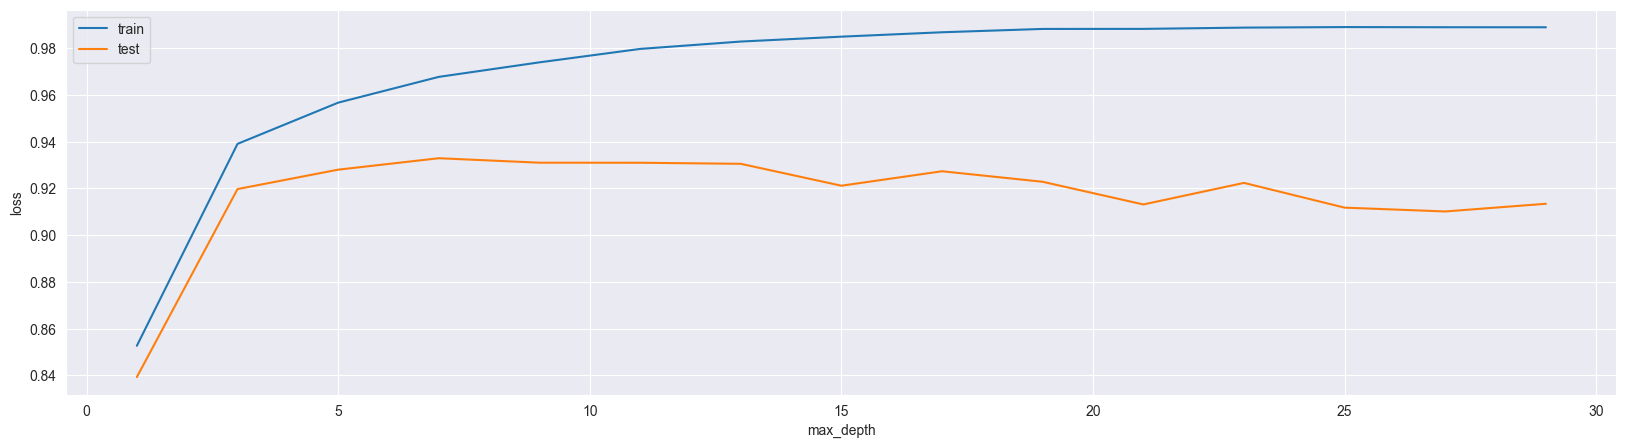

In [7]:
from tqdm import tqdm

results = defaultdict(list)
depths = range(1, 30, 2)

# YOUR CODE:
for depth in tqdm(depths):
    boosting = Boosting(
        base_model_params={"max_depth": depth},
    )
    boosting.fit(x_train, y_train, x_valid, y_valid)
    results["train"].append(boosting.score(x_train, y_train))
    results["valid"].append(boosting.score(x_valid, y_valid))
    results["test"].append(boosting.score(x_test, y_test))

plt.figure(figsize=(20, 5))
sns.lineplot(x=depths, y=results["train"], label="train")
# sns.lineplot(x=depths, y=results["valid"], label="valid")
sns.lineplot(x=depths, y=results["test"], label="test")
plt.xlabel("max_depth")
plt.ylabel("loss")
plt.legend()
plt.show()

**Какая из моделей имеет лучшее качество? Как вы можете это объяснить?** <br>
**Answer:** <br>
The best score on test was achieved on `max_depth`=9, higher values lead to overfit.

## Задание 3. Подбираем гиперпараметры и ищем лучшую модель (2 балла)

Подберите по валидационной выборке основные гиперпараметры для вашей модели бустинга. Следует подобрать все основные параметры для самого градиентного бустинга и для самих базовых моделей.

In [8]:
# YOUR CODE:
results = []

for n_estimators in tqdm([10, 20, 50, 100]):
    for learning_rate in [0.001, 0.01, 0.1]:
        for early_stopping_rounds in [None, 5, 10]:
            for max_depth in depths:

                # define used parameters into dict (we might unpack later)
                params = {
                    "n_estimators": n_estimators,
                    "learning_rate": learning_rate,
                    "early_stopping_rounds": early_stopping_rounds,
                    "base_model_params": {"max_depth": max_depth}
                }

                boosting = Boosting(
                    base_model_params={"max_depth": max_depth},
                    early_stopping_rounds=early_stopping_rounds,
                    learning_rate=learning_rate,
                    n_estimators=n_estimators,
                )
                boosting.fit(x_train, y_train, x_valid, y_valid)
                results.append(
                    {"params": params, "valid_score": boosting.score(x_valid, y_valid)}
                )

100%|██████████| 4/4 [16:40<00:00, 250.19s/it]


In [9]:
best = max(results, key=lambda x: x["valid_score"])

pprint(f"best score on validation set: {best['valid_score']:.5f}")
pprint("achieved with:", best["params"])

>> best score on validation set: 0.94248
>> achieved with: {'n_estimators': 100, 'learning_rate': 0.1, 'early_stopping_rounds': 10, 'base_model_params': {'max_depth': 11}}


In [10]:
# control check on the test sample
boosting = Boosting(**best["params"])
boosting.fit(x_train, y_train, x_valid, y_valid)
pprint(f"score on test set: {boosting.score(x_test, y_test):.5f}")

>> score on test set: 0.93737


## Задание 4. Пробуем разные библиотеки (2 балла)

Выберите себе библиотеку с реализацией градиентного бустинга по вкусу из следующих трёх - [XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_intro.html), [LightGBM](https://lightgbm.readthedocs.io/en/latest/Python-Intro.html), [CatBoost](https://catboost.ai/en/docs/concepts/python-quickstart). Подберите основные гиперпараметры, постарайтесь добиться наилучшего качества на тестовых данных. Сравните результаты своей реализации с результатами библиотечного бустинга.

In [11]:
def score(clf, x, y):
    return roc_auc_score(y == 1, clf.predict_proba(x)[:, 1])

In [12]:
# YOUR CODE:
from catboost import CatBoostClassifier
results = []

for n_estimators in tqdm(np.arange(5, 17, 1)):
    for learning_rate in np.arange(0.1, 1, 0.1):
        for l2_leaf_reg in np.logspace(-1, 2.5, 10):
            for max_depth in np.arange(1, 12, 2):

                # define used parameters into dict (we might unpack later)
                params = {
                    "iterations": n_estimators,
                    "learning_rate": learning_rate,
                    "l2_leaf_reg": l2_leaf_reg,
                    "max_depth": max_depth
                }

                boosting = CatBoostClassifier(loss_function="Logloss",
                                              iterations=n_estimators, learning_rate=learning_rate, max_depth=max_depth, l2_leaf_reg=l2_leaf_reg,
                                              silent=True)
                boosting.fit(x_train, y_train)

                results.append({
                    "params": params, "valid_score": score(boosting, x_valid, y_valid)
                })

100%|██████████| 12/12 [07:22<00:00, 36.84s/it]


In [13]:
best = max(results, key=lambda x: x["valid_score"])

pprint(f"best score on validation set: {best['valid_score']:.5f}")
pprint("achieved with:", best["params"])

>> best score on validation set: 0.94621
>> achieved with: {'iterations': np.int64(16), 'learning_rate': np.float64(0.5), 'l2_leaf_reg': np.float64(0.1), 'max_depth': np.int64(7)}


In [14]:
# control check on the test sample
boosting = CatBoostClassifier(loss_function="Logloss", silent=True, **best["params"])
boosting.fit(x_train, y_train)
pprint(f"best score on test set: {score(boosting, x_test, y_test):.5f}")

>> best score on test set: 0.93516


In [25]:
# also try one without parameters
boosting = CatBoostClassifier(loss_function="Logloss", silent=True)
boosting.fit(x_train, y_train)
pprint(f"best score on test set (no search of parameters): {score(boosting, x_test, y_test):.5f}")

>> best score on test set (no search of parameters): 0.94162


### Задание 5 (бонус). Пробуем ещё немножко библиотек (1 балл)

Существуют библиотеки для подбора гиперпараметров, попробуйте использовать какую-нибудь из следующих двух - [Hyperopt](https://github.com/hyperopt/hyperopt), [Optuna](https://optuna.org/). Сравните полученное качество с вашим ручным перебором. Используйте эту библиотеку чтобы подобрать параметры и для своей реалзиации и для библиотечной.

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1337)
x_test, x_valid, y_test, y_valid = train_test_split(x_test, y_test, test_size=0.5, random_state=1337)

In [16]:
# YOUR CODE:
import optuna
import scipy.sparse
from catboost import Pool, CatBoostClassifier


def objective(trial: optuna.Trial, x_train: scipy.sparse.csr_matrix, y_train: np.ndarray,
              x_valid: scipy.sparse.csr_matrix, y_valid: np.ndarray) -> float:

    # parameters to search on
    param = {
        "loss_function": "Logloss",
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "eval_metric": "Logloss",
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 3, 10.),
        "task_type": "CPU",
        "verbose": 0,
    }

    # data wrappers
    train_pool = Pool(x_train, y_train)
    val_pool = Pool(x_valid, y_valid)

    gbm = CatBoostClassifier(**param)
    gbm.fit(train_pool, eval_set=val_pool, early_stopping_rounds=200)

    return score(gbm, x_valid, y_valid)

In [17]:
study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective(trial, x_train, y_train, x_valid, y_valid), n_trials=20)

[I 2026-03-24 12:53:39,972] A new study created in memory with name: no-name-37571478-e81f-4691-ae6e-08ba5e3bd7e3
[I 2026-03-24 12:53:40,738] Trial 0 finished with value: 0.9292275985705994 and parameters: {'learning_rate': 0.0019421710715182732, 'max_depth': 6, 'iterations': 261, 'l2_leaf_reg': 7.488690321131345}. Best is trial 0 with value: 0.9292275985705994.
[I 2026-03-24 12:53:40,941] Trial 1 finished with value: 0.8990895035491562 and parameters: {'learning_rate': 0.0012095717832545578, 'max_depth': 2, 'iterations': 104, 'l2_leaf_reg': 3.725735601487025}. Best is trial 0 with value: 0.9292275985705994.
[I 2026-03-24 12:53:44,568] Trial 2 finished with value: 0.9381493782491362 and parameters: {'learning_rate': 0.008580008618989866, 'max_depth': 2, 'iterations': 958, 'l2_leaf_reg': 8.269037111390675}. Best is trial 2 with value: 0.9381493782491362.
[I 2026-03-24 12:53:46,870] Trial 3 finished with value: 0.9451694679179108 and parameters: {'learning_rate': 0.04930549811155442, 'ma

In [18]:
pprint(f"the best score on validation set: {study.best_value:.5f}")
pprint("achieved with:", study.best_params)

>> the best score on validation set: 0.94716
>> achieved with: {'learning_rate': 0.04485441301877134, 'max_depth': 4, 'iterations': 580, 'l2_leaf_reg': 5.429069823137366}


In [26]:
# control check on the test sample
boosting = CatBoostClassifier(loss_function="Logloss", verbose=1, **study.best_params, eval_metric="Logloss", task_type="CPU")
boosting.fit(x_train, y_train)
pprint(f"score on test set: {score(boosting, x_test, y_test):.5f}")

0:	learn: 0.6503793	total: 9.33ms	remaining: 5.4s
1:	learn: 0.6091283	total: 12ms	remaining: 3.46s
2:	learn: 0.5757562	total: 14.6ms	remaining: 2.81s
3:	learn: 0.5482930	total: 17.6ms	remaining: 2.53s
4:	learn: 0.5202255	total: 19.9ms	remaining: 2.29s
5:	learn: 0.4961431	total: 22.3ms	remaining: 2.13s
6:	learn: 0.4738466	total: 24.5ms	remaining: 2s
7:	learn: 0.4531046	total: 26.7ms	remaining: 1.91s
8:	learn: 0.4374600	total: 29ms	remaining: 1.84s
9:	learn: 0.4254109	total: 31.8ms	remaining: 1.81s
10:	learn: 0.4146685	total: 34.5ms	remaining: 1.79s
11:	learn: 0.4021999	total: 36.6ms	remaining: 1.73s
12:	learn: 0.3919364	total: 39.3ms	remaining: 1.71s
13:	learn: 0.3834622	total: 42.1ms	remaining: 1.7s
14:	learn: 0.3766437	total: 44.4ms	remaining: 1.67s
15:	learn: 0.3705964	total: 46.7ms	remaining: 1.65s
16:	learn: 0.3635821	total: 49.1ms	remaining: 1.63s
17:	learn: 0.3569955	total: 51.5ms	remaining: 1.61s
18:	learn: 0.3497010	total: 54ms	remaining: 1.59s
19:	learn: 0.3432819	total: 56.9m

## Задание 6. Интерпретация бустинга (1 балл)

Теперь попробуем оценить важность признаков для бустинга.

Поскольку наша базовая модель - это дерево из `sklearn`, мы можем вычислить важность признака отдельно для каждого дерева и усреднить (воспользуйтесь `feature_importances_` у `DecisionTreeRegressor`), после этого нормировать значения, чтобы они суммировались в единицу (обратите внимание, что они должны быть неотрицательными - иначе вы что-то сделали не так).

Допишите в вашей реализации бустинга функцию `feature_importances_` чтобы она возвращала описанные выше важности признаков.

Нарисуйте столбчатую диаграмму важности признаков. На соседнем графике нарисуйте важность признаков для логистической регрессии, для этого используйте модули весов. Сравните графики. Проанализируйте полученные результаты.

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1337)
x_test, x_valid, y_test, y_valid = train_test_split(x_test, y_test, test_size=0.5, random_state=1337)

In [27]:
def plot_calibration_curve(y_test, preds, ax):
    bin_middle_points = []
    bin_real_ratios = []
    n_bins = 10
    for i in range(n_bins):
        l = 1.0 / n_bins * i
        r = 1.0 / n_bins * (i + 1)
        bin_middle_points.append((r + l) / 2)
        bin_real_ratios.append(np.mean(y_test[(preds >= l) & (preds < r)] == 1))
    sns.lineplot(x=bin_middle_points, y=bin_real_ratios, label="Predicted probabilities", ax=ax)
    sns.lineplot(x=bin_middle_points, y=bin_middle_points, label="Probabilities of perfect calibration", linestyle="--", ax=ax)
    ax.set(xlabel="Midpoints of bins", ylabel="Fraction of positive class instances")

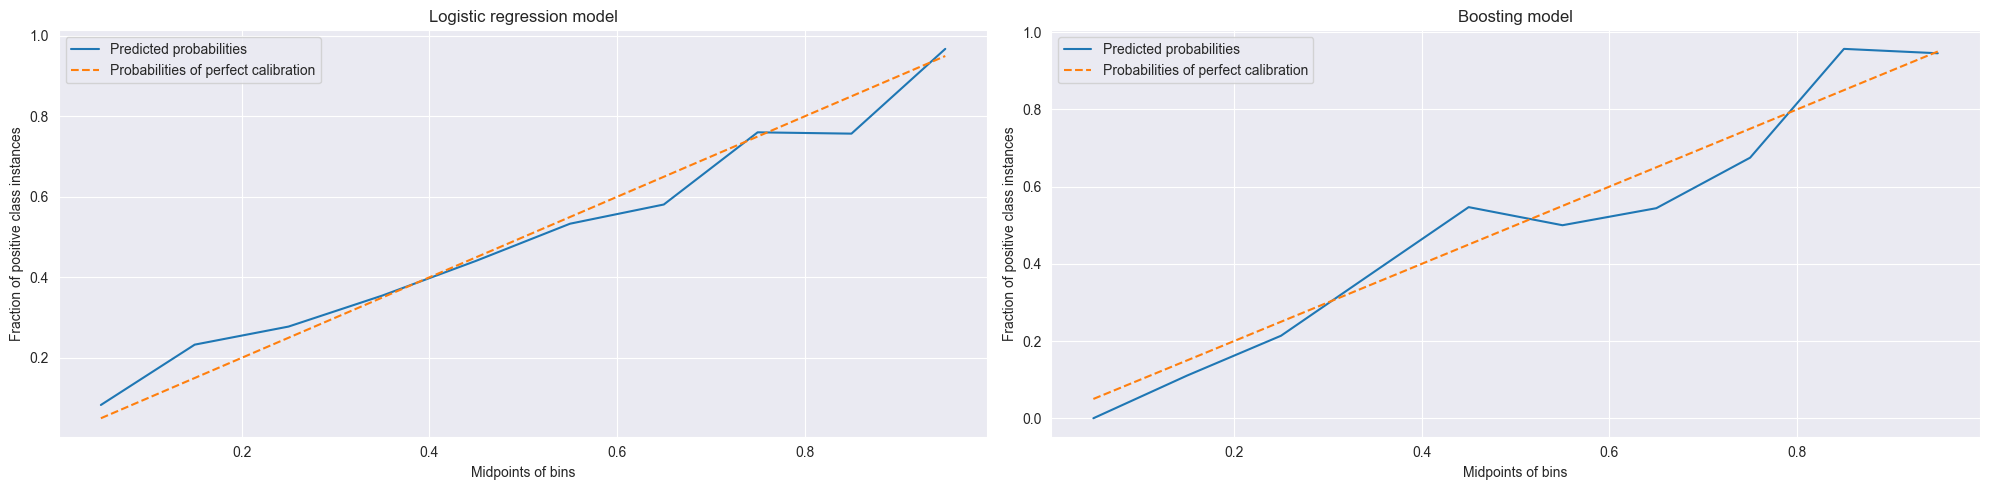

In [51]:
# YOUR CODE:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

fig, axs = plt.subplots(figsize=(20, 5), nrows=1, ncols=2)

model_logit = Pipeline([("lr", LogisticRegression())])
model_logit.fit(x_train, y_train)
plot_calibration_curve(y_test, model_logit.predict_proba(x_test)[:, 1], ax=axs[0])

boosting = Boosting(**{'n_estimators': 100, 'learning_rate': 0.1, 'early_stopping_rounds': 10, 'base_model_params': {'max_depth': 11}})
boosting.fit(x_train, y_train, x_valid, y_valid)
plot_calibration_curve(y_test, boosting.predict_proba(x_test)[:, 1], ax=axs[1])

axs[0].set(title="Logistic regression model")
axs[1].set(title="Boosting model")
plt.tight_layout()
plt.show()

In [105]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=2, cols=1, subplot_titles=["Boosting model", "Logistic regression model"])
fig.update_xaxes(tickangle=45, tickfont=dict(size=10))
fig.update_layout(title_text="Feature importance in two classification models")

features_logit = np.abs(model_logit[0].coef_[0]) / np.sum(np.abs(model_logit[0].coef_[0]))

fig.add_trace(go.Bar(x=np.arange(x_train.shape[1]), y=boosting.feature_importances_), row=1, col=1)
fig.add_trace(go.Bar(x=np.arange(x_train.shape[1]), y=features_logit), row=2, col=1)

fig.update_xaxes(title_text="Feature index", row=2, col=1)
fig.update_yaxes(title_text="Weight (abs)", row=1, col=1)
fig.update_yaxes(title_text="Weight (abs)", row=2, col=1)

Кстати, чаще всего излишние признаки могут вредить качеству бустинга. Попробуйте отфильтровать на основании диаграммы хвост наименее важных признаков и снова обучить модель (с теми же гиперпараметрами). Стало ли лучше?

In [21]:
# YOUR CODE:

## Задание 7 (бонус). Блендинговое (1 балл)

Реализуйте блендинг над вашими лучшими моделями (ваша реализация с лучшими гиперпараметрами + все модели из библиотек с лучшими гиперпараметрами). Улучшилось ли качество?

In [22]:
# YOUR CODE: